# Bài 1:

In [2]:
import DecisionTree
import numpy as np
import pandas as pd

df = pd.read_csv('winequality-red.csv',sep = ';')
print(df.shape)


(1599, 12)


In [3]:
from sklearn.model_selection import train_test_split
X= df.drop('quality', axis=1).values
y = df['quality'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train set:', X_train.shape, y_train.shape)
print('Test set:', X_test.shape, y_test.shape)

Train set: (1279, 11) (1279,)
Test set: (320, 11) (320,)


Đang huấn luyện mô hình Decision Tree
Mô hình đã được huấn luyện
F1 Score: 0.5571848872241045


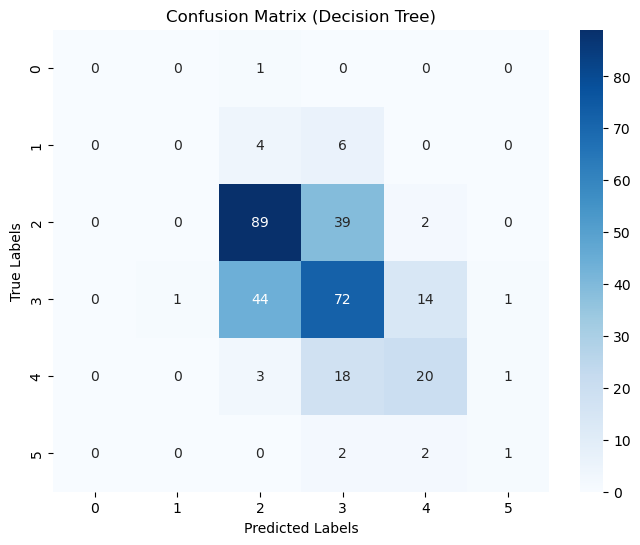

In [4]:
from sklearn.metrics import f1_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('Đang huấn luyện mô hình Decision Tree')
model = DecisionTree.DecisionTree(criterion='cart',n_min = 2,max_depth=10)
model.fit(X_train, y_train)
print('Mô hình đã được huấn luyện')

y_pred = model.predict(X_test)
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') 
plt.title('Confusion Matrix (Decision Tree)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Bài 2:

Đang huấn luyện mô hình Random Forest
Mô hình Random Forest đã được huấn luyện
F1 Score (Random Forest): 0.5904240882103478


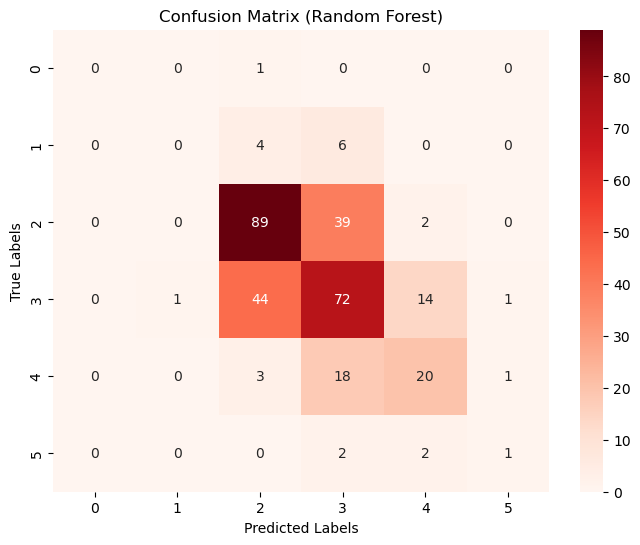

In [5]:
import RandomForest
print('Đang huấn luyện mô hình Random Forest')
model_rf = RandomForest.RandomForest(n_trees=10, n_min=2, max_depth=10, n_features=df.columns.size-1)
model_rf.fit(X_train, y_train)
print('Mô hình Random Forest đã được huấn luyện')
y_pred_rf = model_rf.predict(X_test)
print('F1 Score (Random Forest):', f1_score(y_test, y_pred_rf, average='weighted'))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds') 
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Bài 3: 

F1 Score (Sklearn Decision Tree): 0.5409048546390319
F1 Score (Sklearn Random Forest): 0.6118790584415584


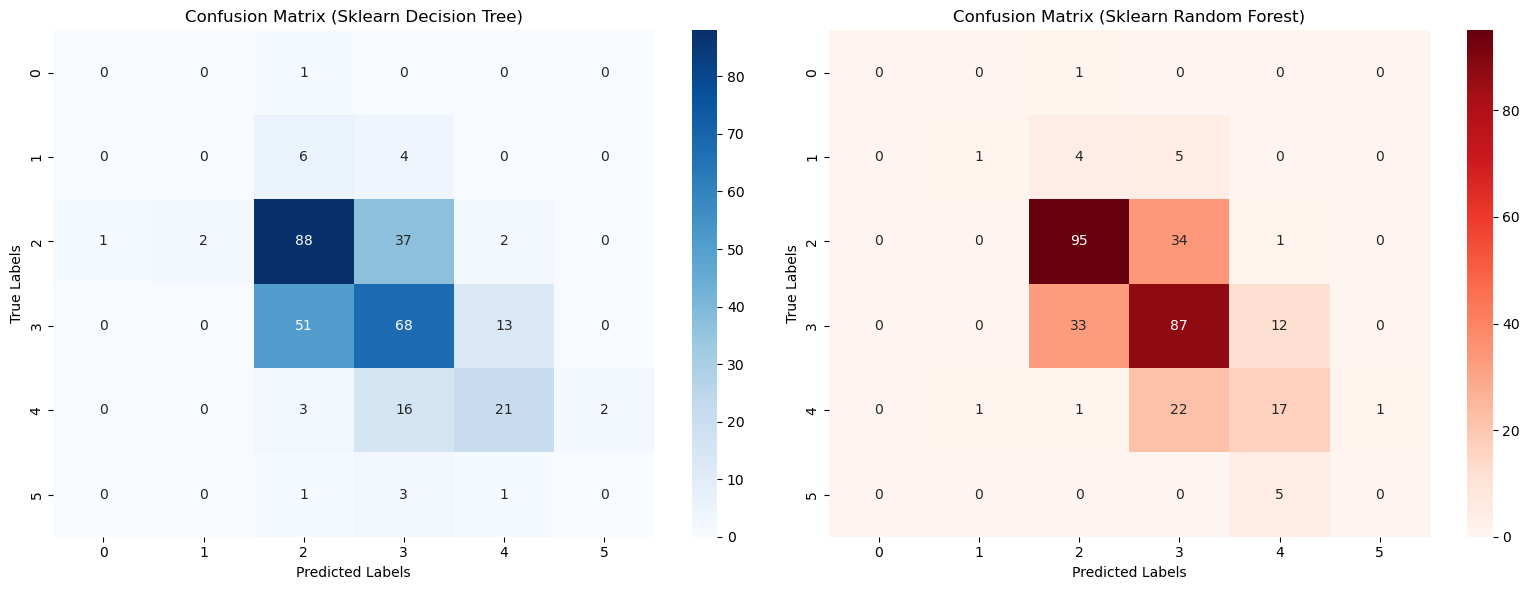

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model_sk_dt = DecisionTreeClassifier(criterion='gini', min_samples_split=2, max_depth=10, random_state=42)
model_sk_dt.fit(X_train, y_train)
y_pred_sk_dt = model_sk_dt.predict(X_test)
print('F1 Score (Sklearn Decision Tree):', f1_score(y_test, y_pred_sk_dt, average='weighted'))
cm_dt = confusion_matrix(y_test, y_pred_sk_dt)


model_sk_rf = RandomForestClassifier(n_estimators=10, min_samples_split=2, max_depth=10, max_features='sqrt', random_state=42)
model_sk_rf.fit(X_train, y_train)
y_pred_sk_rf = model_sk_rf.predict(X_test)
print('F1 Score (Sklearn Random Forest):', f1_score(y_test, y_pred_sk_rf, average='weighted'))
cm_rf = confusion_matrix(y_test, y_pred_sk_rf)

plot, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Sklearn Decision Tree)')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('Confusion Matrix (Sklearn Random Forest)')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')
plt.tight_layout()
plt.show()
